In [3]:
import numpy as np
from typing import Callable, Tuple, List
import matplotlib.pyplot as plt



In [29]:
# Parameters
lambda_S = 0.8
mu_S = 1.0
lambda_R = 0.9
mu_R = 0.4
alpha = 0.02


def gillespie(t_max=100, plot=False):
    resistant_domninance_time = 0
    
    # Initial state: [S, R]
    state = np.array([50, 0], dtype=int)

    time = 0.0

    # Store history
    time_history = [time]
    state_history = [state.copy()]

    max_population = 10000
    max_events = 100000

    event_count = 0

    # Main Gillespie loop
    while time < t_max and np.sum(state) < max_population and event_count < max_events:

        S, R = state

        if R > S:
            if resistant_domninance_time == 0:
                resistant_domninance_time = time

        # Stop if extinct
        if S + R == 0:
            break

        # State-dependent rates
        rates = np.array([
            lambda_S * S,
            mu_S * S,
            lambda_R * R,
            mu_R * R,
            alpha * S
        ])

        total_rate = np.sum(rates)

        if total_rate == 0:
            break

        # Exponential waiting time
        time_to_next_event = -np.log(np.random.rand()) / total_rate
        time += time_to_next_event

        # Choose event
        event_probabilities = rates / total_rate
        event_num = np.random.rand()

        cumulative = np.cumsum(event_probabilities)

        if event_num < cumulative[0]:
            state[0] += 1

        elif event_num < cumulative[1]:
            if state[0] > 0:
                state[0] -= 1

        elif event_num < cumulative[2]:
            state[1] += 1

        elif event_num < cumulative[3]:
            if state[1] > 0:
                state[1] -= 1

        else:
            if state[0] > 0:
                state[0] -= 1
                state[1] += 1

        # Store history
        time_history.append(time)
        state_history.append(state.copy())

        event_count += 1

    # Convert to numpy array for indexing
    state_history = np.array(state_history)

    # Plot
    if plot:
        plt.figure(figsize=(8,5))
        plt.step(time_history, state_history[:, 0],
                 where='post', label='Sensitive Cells (S)')
        plt.step(time_history, state_history[:, 1],
                 where='post', label='Resistant Cells (R)')

        plt.xlabel("Time")
        plt.ylabel("Population")
        plt.title("Tumor Evolution via Gillespie Algorithm")
        plt.legend()
        plt.show()

    return np.array(time_history), state_history, resistant_domninance_time

Initial state: S=50, R=0
Final state: S=0, R=10000
Resistant dominance time: 3.93
Initial state: S=50, R=0
Final state: S=4, R=9996
Resistant dominance time: 3.23
Initial state: S=50, R=0
Final state: S=0, R=10000
Resistant dominance time: 7.80
Initial state: S=50, R=0
Final state: S=0, R=10000
Resistant dominance time: 6.11
Initial state: S=50, R=0
Final state: S=0, R=10000
Resistant dominance time: 4.69
Initial state: S=50, R=0
Final state: S=0, R=10000
Resistant dominance time: 10.59
Initial state: S=50, R=0
Final state: S=0, R=10000
Resistant dominance time: 4.08
Initial state: S=50, R=0
Final state: S=0, R=10000
Resistant dominance time: 4.48
Initial state: S=50, R=0
Final state: S=0, R=10000
Resistant dominance time: 5.98
Initial state: S=50, R=0
Final state: S=0, R=10000
Resistant dominance time: 5.61
Initial state: S=50, R=0
Final state: S=0, R=10000
Resistant dominance time: 5.26
Initial state: S=50, R=0
Final state: S=0, R=0
Extinction occurred.
Initial state: S=50, R=0
Final

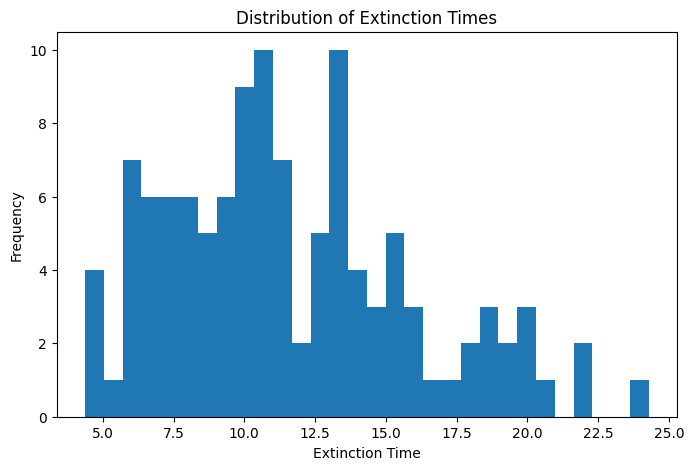

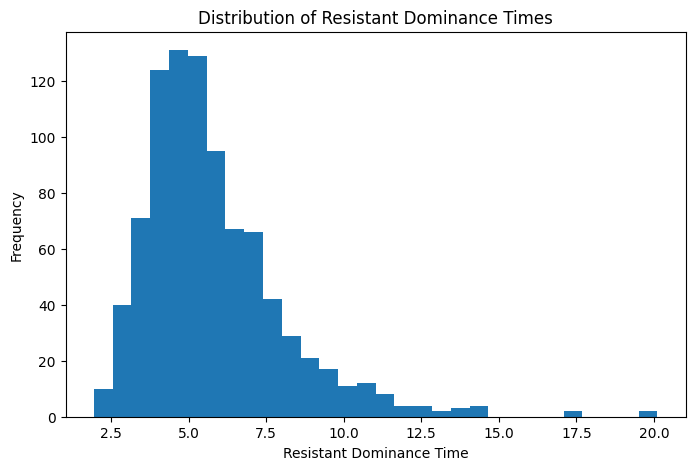

In [28]:
total_simulations = 1000
extinction_count = 0
resistant_dominance_data = []
extinction_data = []
for i in range(total_simulations):
    t_hist, state_hist, resist_time = gillespie()
    print(f"Initial state: S={state_hist[0, 0]}, R={state_hist[0, 1]}")
    print(f"Final state: S={state_hist[-1, 0]}, R={state_hist[-1, 1]}")
    if state_hist[-1, 0] == 0 and state_hist[-1, 1] == 0:
        print("Extinction occurred.")
        extinction_count += 1
        extinction_data.append(t_hist[-1])
    if resist_time > 0:
        print(f"Resistant dominance time: {resist_time:.2f}")
        resistant_dominance_data.append(resist_time)

print(f"P(S + R = 0) = {extinction_count / total_simulations:.4f}")
plt.figure(figsize=(8,5))
plt.hist(extinction_data, bins=30)
plt.xlabel("Extinction Time")
plt.ylabel("Frequency")
plt.title("Distribution of Extinction Times")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(resistant_dominance_data, bins=30)
plt.xlabel("Resistant Dominance Time")
plt.ylabel("Frequency")
plt.title("Distribution of Resistant Dominance Times")
plt.show()

The run of 1000 simulations took about 13 minutes. The distributions were generated, and the P(extinction) was 0.1150. The distribution for extinction first passage time was a bit messy, I think just due to having less data (in 1000 runs, only around 110 will have extinction times, whereas the other 890 will have resistant dominance times) but seemed to have a mean around times 12 or 13, with a heavier tail to the right. The distribution of resistant dominance times is a much cleaner curve with a lighter tail. The mean of resistant dominance time also seemed earlier, around 5.0.